### **Astro 416 Final Project: Classifying Supernova**

##### Import the necessary packages and libraries

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tabulate import tabulate

In [119]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import model_selection
from sklearn import metrics

In [100]:
#adjust plot style, see 
# https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
plt.style.use('seaborn-v0_8-darkgrid')

##### Read in the data

In [108]:
fig_path = '/Users/danielheilman/Documents/college-umich/winter-2025/astro-416/final-project/figures/'

In [ ]:
path = '/Users/danielheilman/Documents/college-umich/winter-2025/astro-416/final-project/supernova-data/'

In [4]:
#we will start by writing a function to read in the data from a file
def read_file(file_path):
    '''
    Reads in the data from the .DAT file

    Returns: pandas dataframe with light curve data from the file
    '''
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    data_pair = []
    data_started = False
    header_data = {}
    data_lines = []
    for line in lines:
        line = line.strip()
        if line.startswith('SNTYPE'):
            key, val = line.split(':', 1)
            snType = int(val.strip()) #extract value and convert to an int
        
        elif line.startswith('VARLIST'):
            columns = line.split(':')[1].strip().split()
            data_started = True
            continue

        elif data_started and line.startswith('OBS'):
            parts = line.split()
            data_lines.append(parts[1:])  # skip the 'OBS:'
            
    df = pd.DataFrame(data_lines, columns=columns)
    for col in ['MJD', 'FLUXCAL', 'FLUXCALERR']:
        df[col] = df[col].astype(float)

    return snType, df

In [5]:
#we will then add a function to read in the data from one of the folders
def read_dataset(path):
    '''
    This function takes in a path and reads in all of the data
    from the files in the folder to which the path points

    Returns: data structure with all of the data from the light curves in the folder
    '''
    fileslist = os.listdir(path)
    files_data = []
    for filename in fileslist:
        data = read_file(path + filename)
        files_data.append(data)
        
    return files_data

In [6]:
dataset = read_dataset(path)

In [7]:
print(dataset[0])

(-9,           MJD FLT FIELD  FLUXCAL  FLUXCALERR
0   56171.051   g  NULL   3.1850      78.080
1   56172.039   r  NULL  -1.9920      17.590
2   56172.051   i  NULL -13.0100      49.950
3   56176.160   z  NULL  23.2100       3.614
4   56179.023   g  NULL  11.6300       6.417
..        ...  ..   ...      ...         ...
88  56296.051   z  NULL   0.8663       4.461
89  56305.043   g  NULL   1.9180       2.872
90  56305.051   r  NULL   3.7050       2.175
91  56305.055   i  NULL   2.8220       3.047
92  56305.070   z  NULL   6.0610       3.665

[93 rows x 5 columns])


##### Construct Features & Targets

In [8]:
# we will start by finding our sets for which we do or do not know the SN type
known = []
unknown = []
for data in dataset:
    if data[0] == -9:
        unknown.append(data)
    else:
        known.append(data)
print(len(known), len(unknown))

1279 17068


In [9]:
#store the target values for all of our supernova with known types
targets = np.array(list(map(lambda x: x[0], known)))
print(len(targets))

1279


In [ ]:
#store the light curves data for the supernova with known types
light_curves = list(map(lambda x: x[1], known))
print(len(light_curves))

light_curves[0]

1279


,MJD,FLT,FIELD,FLUXCAL,FLUXCALERR
0,56281.160,g,NULL,-0.72700,2.074
1,56281.184,r,NULL,0.21140,1.273
2,56281.203,i,NULL,-1.60700,1.799
3,56281.227,z,NULL,-0.51860,2.290
4,56288.086,g,NULL,6.02900,4.859
5,56288.094,r,NULL,-0.05802,2.114
6,56288.109,i,NULL,0.74160,3.059
7,56288.141,z,NULL,0.03492,2.584
8,56289.227,g,NULL,11.88000,6.502
9,56289.242,r,NULL,6.32500,2.704


In [ ]:
def returnLength(dataframe):
    """
    Returns the length of the longest light curve out of all the filters in the dataframe
    """
    lengths = np.zeros(4)
    lengths[0] = len(np.where(dataframe['FLT'] == 'g')[0])
    lengths[1] = len(np.where(dataframe['FLT'] == 'r')[0])
    lengths[2] = len(np.where(dataframe['FLT'] == 'i')[0])
    lengths[3] = len(np.where(dataframe['FLT'] == 'z')[0])
    return np.max(lengths)

In [ ]:
#find the light curves with the longest filter light curve
longest = max(list(map(returnLength, light_curves)))
longest

37.0

In [ ]:
def makeFeatures(dataframe, longest):
    '''
    Takes in a dataframe of light curve data, extracts the relevant data for the features, 
    and packages it so it can be used as a feature for an associated target

    Time is taken relative to the first time recorded

    Parameters:
        dataframe: dataframe holding the light curve data
        longest: parameter describing the longest light curve in the set
            this will be used to make all the data the same size 
    Returns: feature: 1d list with the light curves for each of the four bands
        format: [time0, flux0, time1, flux1, ...]
    '''
    #store time as time from the initial time
    time = dataframe['MJD'] - dataframe['MJD'].iloc[0]
    #create masks for each of the filters
    g_mask = dataframe['FLT'] == 'g'
    r_mask = dataframe['FLT'] == 'r'
    i_mask = dataframe['FLT'] == 'i'
    z_mask = dataframe['FLT'] == 'z'
    #apply masks to store (time, flux) pairs for each filter
    g = (time[g_mask], dataframe['FLUXCAL'][g_mask])
    r = (time[r_mask], dataframe['FLUXCAL'][r_mask])
    i = (time[i_mask], dataframe['FLUXCAL'][i_mask])
    z = (time[z_mask], dataframe['FLUXCAL'][z_mask])
    #package together in list
    filts = [g, r, i, z]
    filt_flat = []
    #lengthen all filters with padding to have the same size as the longest 
    time_pad = 999.0
    flux_pad = 0.0
    #step through each filter
    for i in range(len(filts)):
        #determine how much padding is needed
        pad_len = int(longest - len(filts[i][0]))
        if pad_len > 0:  #if no padding is needed, skip
            #use numpy padding function to pad the time and flux vals to the same size
            padded_time = np.pad(filts[i][0], (0, pad_len), constant_values=time_pad)
            padded_flux = np.pad(filts[i][1], (0, pad_len), constant_values=flux_pad)
            filts[i] = np.array([padded_time, padded_flux])
        #we will need a 1d array for scikit-learn functions, flatten each filter and store
        flattened = np.column_stack((filts[i][0], filts[i][1])).flatten()
        filt_flat.append(flattened)
    #combine 1d flattened filter arrays into a 1d array for the SN
    feature = np.concatenate(filt_flat)
    return feature

In [28]:
#extract features usable with scikit-learn from the light curves data, apply any desired feature engineering
features = np.array(list(map(lambda x: makeFeatures(x, longest), light_curves)))
print(len(features), len(features[0]))

1279 296


##### Data Exploration

In [223]:
#since confusion matrix will return the categories in sorted order, we will put ours in sorted order as well
SN_types = ['Ia','Ibc', 'IIn', 'IIP', 'IIL', 'Ib', 'Ic']
integer_codes = [1, 3, 21, 22, 23, 32, 33]
count = []

for i in range(len(SN_types)):
    count.append(len(targets[targets == integer_codes[i]]))

headers = ['SN Types', 'Count']
table_data = zip(*[SN_types, count])
table = tabulate(table_data, headers)
print(table)

SN Types      Count
----------  -------
Ia              834
Ibc              13
IIn              48
IIP             236
IIL              13
Ib               73
Ic               62


In [224]:
largest_class = SN_types[np.argmax(count)]
print("The total number of targets is {}, with the largest class being Type {} supernova, with {} SN.".format(len(targets), largest_class, np.max(count)))

The total number of targets is 1279, with the largest class being Type Ia supernova, with 834 SN.


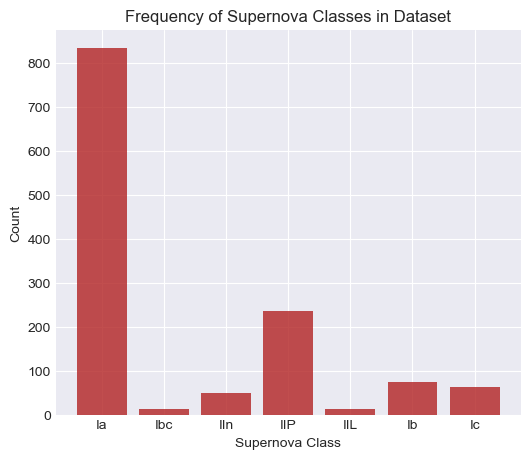

In [225]:
figname = 'class_freq.png'

plt.figure(figsize=(6,5))
plt.bar(SN_types, count, color='firebrick', alpha=0.8)
plt.title("Frequency of Supernova Classes in Dataset")
plt.xlabel("Supernova Class")
plt.ylabel("Count")
plt.savefig(fig_path + figname)

##### Benchmarking

Establish a benchmark for model performance using the default parameters

In [256]:
#benchmark with the default values for random forests
bench_model = RandomForestClassifier(max_depth=None, max_features=None, min_samples_leaf=1, n_estimators=50, criterion='gini', random_state=13) 

In [257]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(features, targets, test_size=0.3, random_state=21)

In [258]:
#fit the benchmark
bench_model.fit(X_train, y_train)

RandomForestClassifier(max_features=None, n_estimators=50, random_state=13)

In [259]:
#print resulting stats
y_pred = bench_model.predict(X_test)

In [288]:
# Print accuracy, recall, and precision for the training set
print('Default Random Forests Training Metrics')
print("accuracy:", metrics.accuracy_score(y_train, bench_model.predict(X_train)))
print("recall:", metrics.recall_score(y_train, bench_model.predict(X_train), average='macro'))
print("precision:", metrics.precision_score(y_train, bench_model.predict(X_train), average='macro'))
print("F statistic:", metrics.f1_score(y_train, bench_model.predict(X_train), average='macro'), '\n')

# Print accuracy, recall, and precision for the testing set
print('Default Random Forests Testing Metrics')
print("accuracy:", metrics.accuracy_score(y_test, bench_model.predict(X_test)))
print("recall:", metrics.recall_score(y_test, bench_model.predict(X_test), average='macro'))
print("precision:", metrics.precision_score(y_test, bench_model.predict(X_test), average='macro'))
print("F statistic:", metrics.f1_score(y_test, bench_model.predict(X_test), average='macro'))

Default Random Forests Training Metrics
accuracy: 1.0
recall: 1.0
precision: 1.0
F statistic: 1.0 

Default Random Forests Testing Metrics
accuracy: 0.8020833333333334
recall: 0.3030424938195247
precision: 0.41510451983580143
F statistic: 0.3205599436713872


/Users/danielheilman/anaconda3/envs/astro-416/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [261]:
#this is the confusion matrix function from the Chapter 3 companion assignment
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues,
                          figname = 'confusion.png',
                          savefig_ = True):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.

    Inputs
    cm: confusion matrix (2D numpy array)
    classes: list of class labels
    normalize: whether to normalize the matrix
    title: title of the plot
    cmap: color map for the plot
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(7,6))
    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", verticalalignment="center",
                 color="green" if i == j else "red", fontsize = 30)

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(fig_path + figname)

In [262]:
# build the confusion matrix
cm_bench = metrics.confusion_matrix(y_test, bench_model.predict(X_test))
print(cm_bench)

[[257   0   0   4   1   0   0]
 [  2   0   0   0   0   0   0]
 [  7   0   0   9   0   0   0]
 [ 20   0   0  47   0   0   0]
 [  2   0   0   0   1   1   0]
 [ 10   0   0   2   0   2   1]
 [ 13   0   0   1   0   3   1]]


Confusion matrix, without normalization
[[257   0   0   4   1   0   0]
 [  2   0   0   0   0   0   0]
 [  7   0   0   9   0   0   0]
 [ 20   0   0  47   0   0   0]
 [  2   0   0   0   1   1   0]
 [ 10   0   0   2   0   2   1]
 [ 13   0   0   1   0   3   1]]


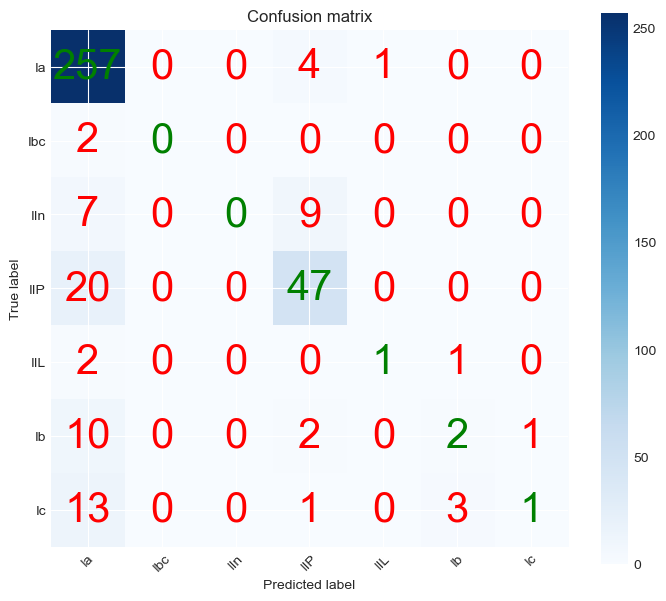

In [263]:
plot_confusion_matrix(cm_bench, SN_types, figname='confusion_bench.png')

##### Build the Model: Initial Attempt at Changing Random-Forests Parameters

In [268]:
#For our initial attempt at changing results, we will limit the max_depth in order to decrease variance, and double the number of estimators
model1 = RandomForestClassifier(max_depth=10, max_features=None, min_samples_leaf=1, n_estimators=100, criterion='gini', random_state=21)

In [269]:
model1.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features=None, random_state=21)

In [270]:
#print resulting stats
y_pred = model1.predict(X_test)

##### Performance Metrics

In [289]:
# Print accuracy, recall, and precision for the training set
print('Non-Default Random Forests Training Metrics')
print("accuracy:", metrics.accuracy_score(y_train, model1.predict(X_train)))
print("recall:", metrics.recall_score(y_train, model1.predict(X_train), average='macro'))
print("precision:", metrics.precision_score(y_train, model1.predict(X_train), average='macro'))
print("F statistic:", metrics.f1_score(y_train, model1.predict(X_train), average='macro'), '\n')

# Print accuracy, recall, and precision for the testing set
print('Non-Default Random Forests Testing Metrics')
print("accuracy:", metrics.accuracy_score(y_test, model1.predict(X_test)))
print("recall:", metrics.recall_score(y_test, model1.predict(X_test), average='macro'))
print("precision:", metrics.precision_score(y_test, model1.predict(X_test), average='macro'))
print("F statistic:", metrics.f1_score(y_test, model1.predict(X_test), average='macro'))

Non-Default Random Forests Training Metrics
accuracy: 0.964245810055866
recall: 0.8878943043399276
precision: 0.9924314096499527
F statistic: 0.932239305555809 

Non-Default Random Forests Testing Metrics
accuracy: 0.8098958333333334
recall: 0.31524375577582825
precision: 0.5088891690833438
F statistic: 0.3444566507587457


/Users/danielheilman/anaconda3/envs/astro-416/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The accuracy is a tad bit lower, but we were able to increase the recall and precision values!  It is notable that the precision value is undefined for some of the classes, as they have no true positives.  The variance seems to have gone down, as the score for the training data is no longer 100%.

In [272]:
# build the confusion matrix
cm = metrics.confusion_matrix(y_test, model1.predict(X_test))
print(cm)

[[258   0   0   4   0   0   0]
 [  2   0   0   0   0   0   0]
 [  6   0   0  10   0   0   0]
 [ 19   0   0  48   0   0   0]
 [  3   0   0   0   1   0   0]
 [  8   0   0   3   0   3   1]
 [ 13   0   0   1   0   3   1]]


Confusion matrix, without normalization
[[258   0   0   4   0   0   0]
 [  2   0   0   0   0   0   0]
 [  6   0   0  10   0   0   0]
 [ 19   0   0  48   0   0   0]
 [  3   0   0   0   1   0   0]
 [  8   0   0   3   0   3   1]
 [ 13   0   0   1   0   3   1]]


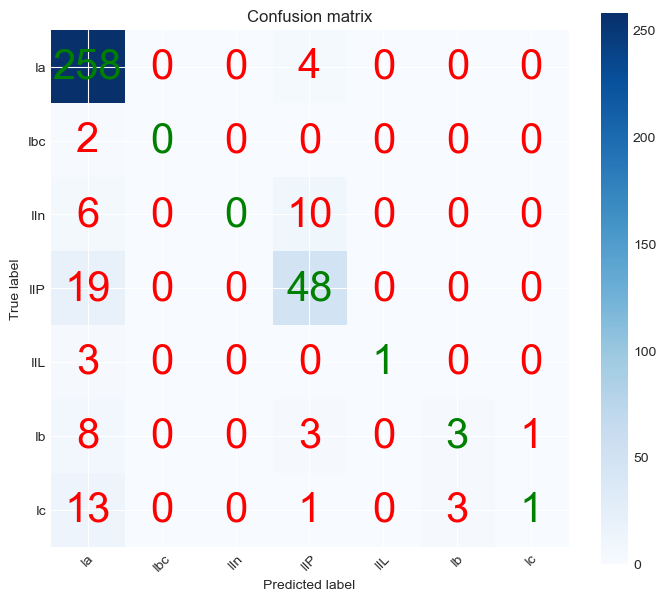

In [273]:
plot_confusion_matrix(cm, SN_types, figname='confusion0.png')

##### Assessing performance:

Our classifier is doing really well with the type Ia and IIL supernova, and is also doing alright with Ib, being 50/50.  It did not however, predict any other types of supernova, and predicted some supernova as IIL when they were in fact other types.  I am personally surprised that it didn't predict any IIP supernova, since this is the second most common type.

##### Employ Cross Validation

In [193]:
#cross validation with shuffling
cv1 = model_selection.KFold(shuffle = True, n_splits = 5, random_state=5)

#cross validation with representative samples
cv2 = model_selection.StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)

In [ ]:
#cross validataion with technique 1
scores1 = model_selection.cross_validate(RandomForestClassifier(), features, targets, cv = cv1, scoring='precision_macro0')

#cross validataion with technique 2
scores2 = model_selection.cross_validate(RandomForestClassifier(), features, targets, cv = cv2, scoring='precision_macro')

/Users/danielheilman/anaconda3/envs/astro-416/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/danielheilman/anaconda3/envs/astro-416/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/danielheilman/anaconda3/envs/astro-416/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [290]:
# Print the mean and standard deviation of CV Kfold technique 1
print("CV Kfold technique 1:")
print("mean: ", np.mean(scores1['test_score']))
print("standard deviation: ", np.std(scores1['test_score']), '\n')

# Print the mean and standard deviation of CV Kfold technique 2
print("CV Kfold technique 2:")
print("mean: ", np.mean(scores2['test_score']))
print("standard deviation: ", np.std(scores2['test_score']), '\n')

CV Kfold technique 1:
mean:  0.4358478897876286
standard deviation:  0.05987507999149872 

CV Kfold technique 2:
mean:  0.4021514998471519
standard deviation:  0.09604620379585704 



##### Employ Grid Search Cross Validation

In [201]:
param_grid = {'max_depth': [None, 3, 5, 7, 10], 'max_features': [None, 1, 2, 5], 'min_samples_leaf': [1, 5, 10], 'n_estimators': [20, 50, 100, 200], 'criterion':['gini']}

In [ ]:
grid_search = model_selection.GridSearchCV(RandomForestClassifier(),
                           param_grid=param_grid)
grid_search.fit(X_train, y_train)

RandomForestClassifier(max_features=None, n_estimators=200)


In [278]:
print(grid_search.best_estimator_)

RandomForestClassifier(max_features=None, n_estimators=200)


The grid search seems to think that a max_features of None, and a n_estimators=200 is the best fit.  I will check out how it does.

In [293]:
#print resulting stats
grid_y_pred_train = grid_search.best_estimator_.predict(X_train)
grid_y_pred_test = grid_search.best_estimator_.predict(X_test)

In [294]:
# Print accuracy, recall, and precision for the training set
print('Grid-Search Random Forests Training Metrics')
print("accuracy:", metrics.accuracy_score(y_train, grid_y_pred_train))
print("recall:", metrics.recall_score(y_train, grid_y_pred_train, average='macro'))
print("precision:", metrics.precision_score(y_train, grid_y_pred_train, average='macro'))
print("F statistic:", metrics.f1_score(y_train, grid_y_pred_train, average='macro'), '\n')

# Print accuracy, recall, and precision for the testing set
print('Grid-Search Random Forests Testing Metrics')
print("accuracy:", metrics.accuracy_score(y_test, grid_y_pred_test))
print("recall:", metrics.recall_score(y_test, grid_y_pred_test, average='macro'))
print("precision:", metrics.precision_score(y_test, grid_y_pred_test, average='macro'))
print("F statistic:", metrics.f1_score(y_test, grid_y_pred_test, average='macro'))

Grid-Search Random Forests Training Metrics
accuracy: 1.0
recall: 1.0
precision: 1.0
F statistic: 1.0 

Grid-Search Random Forests Testing Metrics
accuracy: 0.8098958333333334
recall: 0.3258096106164922
precision: 0.4465331863390115
F statistic: 0.34915921789827215


/Users/danielheilman/anaconda3/envs/astro-416/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [279]:
# build the confusion matrix
cm_grid = metrics.confusion_matrix(y_test, y_pred_test)
print(cm_grid)

[[257   0   0   5   0   0   0]
 [  2   0   0   0   0   0   0]
 [  7   0   0   9   0   0   0]
 [ 19   0   0  48   0   0   0]
 [  3   0   0   0   1   0   0]
 [  8   0   0   2   0   5   0]
 [ 13   0   0   1   0   4   0]]


Confusion matrix, without normalization
[[257   0   0   5   0   0   0]
 [  2   0   0   0   0   0   0]
 [  7   0   0   9   0   0   0]
 [ 19   0   0  48   0   0   0]
 [  3   0   0   0   1   0   0]
 [  8   0   0   2   0   5   0]
 [ 13   0   0   1   0   4   0]]


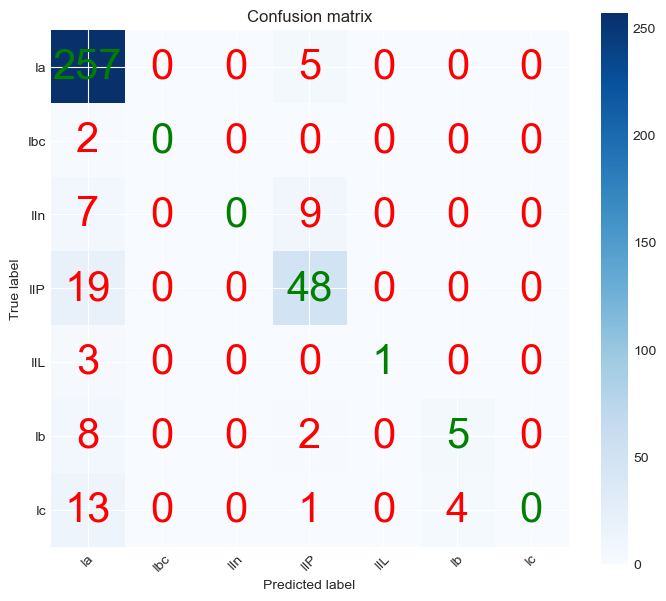

In [280]:
plot_confusion_matrix(cm_grid, SN_types, figname='confusion_grid.png')

##### Balance Class weight to adjust for unequal distribution

In [ ]:
#check best params
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'min_samples_leaf': 1,
 'n_estimators': 200}

In [281]:
#Here we will use the best result from the grid search, while using balanced class weights in order to attempt to account for the large number of type 1a
model2 = RandomForestClassifier(max_depth=None, max_features=None, min_samples_leaf=1, n_estimators=200, criterion='gini', random_state=21, class_weight='balanced')

In [282]:
model2.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_features=None,
                       n_estimators=200, random_state=21)

In [283]:
#print resulting stats
y_pred_train = model2.predict(X_train)
y_pred_test = model2.predict(X_test)

In [292]:
# Print accuracy, recall, and precision for the training set
print('Balanced Random Forests Training Metrics')
print("accuracy:", metrics.accuracy_score(y_train, y_pred_train))
print("recall:", metrics.recall_score(y_train, y_pred_train, average='macro'))
print("precision:", metrics.precision_score(y_train, y_pred_train, average='macro'))
print("F statistic:", metrics.f1_score(y_train, y_pred_train, average='macro'), '\n')

# Print accuracy, recall, and precision for the testing set
print('Balanced Random Forests Testing Metrics')
print("accuracy:", metrics.accuracy_score(y_test, y_pred_test))
print("recall:", metrics.recall_score(y_test, y_pred_test, average='macro'))
print("precision:", metrics.precision_score(y_test, y_pred_test, average='macro'))
print("F statistic:", metrics.f1_score(y_test, y_pred_test, average='macro'))

Balanced Random Forests Training Metrics
accuracy: 1.0
recall: 1.0
precision: 1.0
F statistic: 1.0 

Balanced Random Forests Testing Metrics
accuracy: 0.8151041666666666
recall: 0.32471758347484675
precision: 0.7682892472627042
F statistic: 0.3705297000833001


/Users/danielheilman/anaconda3/envs/astro-416/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Excellent!  This has increased our precision a great deal.

In [285]:
# build the confusion matrix
cm_balanced = metrics.confusion_matrix(y_test, y_pred_test)
print(cm_balanced)

[[259   0   0   2   0   1   0]
 [  2   0   0   0   0   0   0]
 [  7   0   1   8   0   0   0]
 [ 19   0   0  48   0   0   0]
 [  3   0   0   0   1   0   0]
 [ 12   0   0   0   0   3   0]
 [ 16   0   0   1   0   0   1]]


Confusion matrix, without normalization
[[259   0   0   2   0   1   0]
 [  2   0   0   0   0   0   0]
 [  7   0   1   8   0   0   0]
 [ 19   0   0  48   0   0   0]
 [  3   0   0   0   1   0   0]
 [ 12   0   0   0   0   3   0]
 [ 16   0   0   1   0   0   1]]


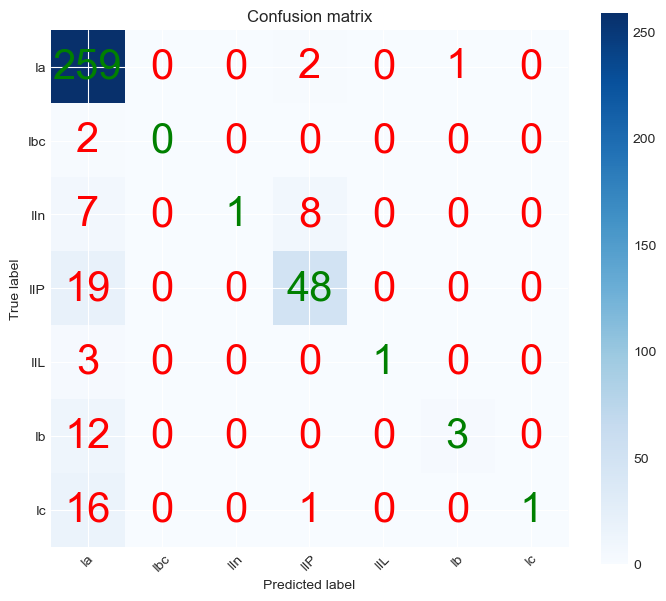

In [286]:
plot_confusion_matrix(cm_balanced, SN_types, figname='confusion_balanced.png')

All in all, the model still overclassifies to the Ia category, but does a better job than it previously did with the others along the diagonal.  I think that because of the high accuracy, with the large boost to precision, this is the best model yet.  Given the high values for both of these metrics, I would say the model is effective at classifying the SN lightcurves